# Sentiment Analysis — Solution

The ultimate goal is to perform sentiment analysis on tweets using two approaches:

1. **Traditional NLP**: bag-of-words features + Naive Bayes classifier
2. **GPT**: prompt-based classification via the OpenAI API

Dataset: [Tweets Sentiment Dataset](https://www.kaggle.com/datasets/yasserh/twitter-tweets-sentiment-dataset) from Kaggle.

## The Dataset

**1. Import Dataset as a pandas dataframe**

In [1]:
# Check that the working directory ends with session_8
%pwd

'c:\\Users\\ezgio\\teaching_local\\dbe\\tutorials\\session_8'

In [4]:
import pandas as pd
import seaborn as sns

df = pd.read_csv("Tweets.csv")

**2. Describe Dataset (text and graphs)**

In [5]:
df.head(10)

,textID,text,selected_text,sentiment
0,cb774db0d1,"I`d have responded, if I were going","I`d have responded, if I were going",neutral
1,549e992a42,Sooo SAD I will 🦈 miss you here in San Diego!!!,Sooo SAD,negative
2,088c60f138,my boss is bullying me...,bullying me,negative
3,9642c003ef,what interview! leave me alone,leave me alone,negative
4,358bd9e861,"Sons of ****, why couldn`t they put them on t...","Sons of ****,",negative
5,28b57f3990,http://www.dothebouncy.com/smf - some shameles...,http://www.dothebouncy.com/smf - some shameles...,neutral
6,6e0c6d75b1,2am feedings for the baby are fun when he is a...,fun,positive
7,50e14c0bb8,Soooo high,Soooo high,neutral
8,e050245fbd,Both of you,Both of you,neutral
9,fc2cbefa9d,Journey!? Wow... u just became cooler. hehe....,Wow... u just became cooler.,positive


In [6]:
# Proportion of each sentiment class
df['sentiment'].value_counts() / len(df['sentiment'])

sentiment
neutral     0.404570
positive    0.312288
negative    0.283141
Name: count, dtype: float64

<Axes: xlabel='sentiment', ylabel='Count'>

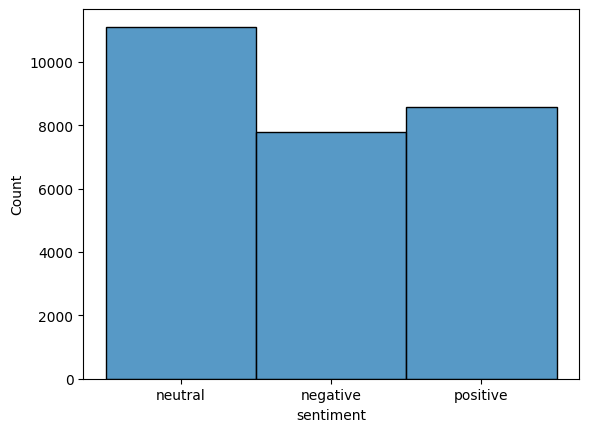

In [7]:
sns.histplot(df['sentiment'])

In [8]:
# Numeric summary — useful to see counts and check for obvious issues
df.describe()

,textID,text,selected_text,sentiment
count,27481,27480,27480,27481
unique,27481,27480,22463,3
top,cb774db0d1,"I`d have responded, if I were going",good,neutral
freq,1,1,199,11118


In [9]:
# Count missing values in the selected_text column
print("Missing values:", sum(df['selected_text'].isna()))

# Remove rows with missing selected_text  (~  means NOT)
df = df[~df['selected_text'].isna()]

# Count how many tweets mention the word 'business'
# .str.count() searches for a pattern in every row of a text column
print("Tweets mentioning 'business':", sum(df['selected_text'].str.count('business')))

Missing values: 1
Tweets mentioning 'business': 24


**3. Split Dataset into training and test set. What is the purpose of the validation set?**

We split data into:
- **Training set**: used to fit the model
- **Test set**: used to evaluate performance at the end

A **validation set** would be a third split used to tune model choices (e.g. choosing between classifiers) — keeping the test set untouched until the very end gives an unbiased estimate of final performance.

In [10]:
from sklearn.model_selection import train_test_split

df_train, df_test = train_test_split(df, random_state=123)

# Inspect the training set
df_train

,textID,text,selected_text,sentiment
24126,52a34843de,"Zeb has napped for 6 hours already today, and ...",he must be growing fast,positive
8513,f1049a3c9c,"good stuff, cant wait for the results","good stuff,",positive
10881,2cc253edc6,I have the best bestfriend in the whole world...,best,positive
10826,e1a023ed94,not good you`re not comin close to where i lo...,not good you`re not comin close to where i lov...,neutral
7852,d442dd8d79,Maybe until Wednesday?,Maybe until Wednesday?,neutral
...,...,...,...,...
15378,cfbec13b5d,"_dam haha, that would be cool. brianna and i s...","haha, that would be cool.",positive
21603,dc582b9f85,YAY!! that`s so cool aww that woulda been sw...,! I`m just glad,positive
17731,1d36d815e9,i knoww she is da best!,a best,positive
15726,a0d6b5cd94,**** the day flies when u got 3647 things to d...,**** the day flies when u got 3647 things to d...,negative


## Text Mining

The goal is to build a tweet classifier that predicts sentiment from text alone — no human input.

**1. Extract features from the training dataset. What do you do with non-words / punctuation?**

Machine learning models cannot work with raw text directly — text must first be converted into numbers.

Let's walk through how text is transformed step by step:

1. **Tokenization** — split text into individual words
2. **Lowercasing + punctuation removal** — standardize and clean tokens
3. **Stopword removal** — drop very common words (*the*, *is*, *a*) that carry no sentiment signal
4. **Lemmatization** — reduce words to their base form (*running* → *run*)
5. **Bag of Words** — count how often each word appears (the numerical feature matrix)

In [11]:
df["text"].head()

0                  I`d have responded, if I were going
1      Sooo SAD I will 🦈 miss you here in San Diego!!!
2                            my boss is bullying me...
3                       what interview! leave me alone
4     Sons of ****, why couldn`t they put them on t...
Name: text, dtype: object

In [12]:
# Step 1: Tokenization — split a tweet into individual words
import nltk
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)
from nltk.tokenize import word_tokenize

example = df["text"].iloc[0]
tokens = word_tokenize(example)
tokens

['I', '`', 'd', 'have', 'responded', ',', 'if', 'I', 'were', 'going']

In [13]:
# Step 2: Lowercase and remove punctuation
# word.isalpha() returns True only for alphabetic tokens — drops numbers and punctuation
tokens_clean = [
    word.lower()
    for word in tokens
    if word.isalpha()
]

tokens_clean

['i', 'd', 'have', 'responded', 'if', 'i', 'were', 'going']

In [14]:
# Step 3: Remove stopwords — common words that add no sentiment signal
nltk.download('stopwords', quiet=True)
from nltk.corpus import stopwords

stop_words = set(stopwords.words("english"))

tokens_nostop = [
    word
    for word in tokens_clean
    if word not in stop_words
]

tokens_nostop

['responded', 'going']

In [15]:
# Step 4: Lemmatization — reduce words to their base form
nltk.download('wordnet', quiet=True)
from nltk.stem import WordNetLemmatizer

lemmatizer = WordNetLemmatizer()

tokens_lemma = [
    lemmatizer.lemmatize(word)
    for word in tokens_nostop
]

tokens_lemma

['responded', 'going']

In practice, `CountVectorizer` already handles steps 1 and 2 (tokenization, lowercasing, punctuation removal) automatically. Steps 3 and 4 give additional control but are not always necessary for a first model.

**We will therefore apply `CountVectorizer` directly to the raw text** — this keeps the pipeline simple and consistent with the tutorial.

In [18]:
from sklearn.feature_extraction.text import CountVectorizer

count_vect = CountVectorizer()

# fit_transform: learn the vocabulary on training data AND count words
# We fit only on the training set so no information from the test set leaks in
X_train = count_vect.fit_transform(df_train['selected_text'])

# Inspect the result: (n_tweets, vocabulary_size)
X_train

<Compressed Sparse Row sparse matrix of dtype 'int64'
	with 129423 stored elements and shape (20610, 14807)>

**2. Convert occurrences to frequencies. Make another version with TF-IDF.**

Raw counts can be biased by tweet length. Two common normalizations:

- **TF** (Term Frequency, `use_idf=False`): divide counts by tweet length
- **TF-IDF** (`use_idf=True`): also down-weight words that appear in many tweets — common words carry less information

In [20]:
from sklearn.feature_extraction.text import TfidfTransformer

# TF only: normalize by tweet length
tf_transformer = TfidfTransformer(use_idf=False).fit(X_train)
X_train_tf = tf_transformer.transform(X_train)
X_train_tf.shape

(20610, 14807)

In [21]:
# TF-IDF: also penalize very common words
tfidf_transformer = TfidfTransformer(use_idf=True).fit(X_train)
X_train_tfidf = tfidf_transformer.transform(X_train)
X_train_tfidf.shape

(20610, 14807)

Both have the same shape — the dimensions don't change, only the values. We'll use **TF-IDF** for the classifier below.

**3. Choose a classifier to predict the sentiment on the test set. Compute the confusion matrix.**

We use **Multinomial Naive Bayes** — a classic and fast text classifier that learns which words are more common in positive vs. negative vs. neutral tweets.



In [ ]:
# Apply the same vocabulary and TF-IDF weights to the test set
# Important: we use`transform` not `fit_transform`, on the test set. 
# The vocabulary and weights come from the training data only.
X_test = count_vect.transform(df_test['selected_text'])
X_test_tfidf = tfidf_transformer.transform(X_test)

In [23]:
from sklearn.naive_bayes import MultinomialNB

clf = MultinomialNB().fit(X_train_tfidf, df_train['sentiment'])

In [24]:
prediction = clf.predict(X_test_tfidf)

In [26]:
from sklearn.metrics import confusion_matrix

mat = confusion_matrix(prediction, df_test['sentiment'])
mat


array([[1112,   50,   37],
       [ 752, 2687,  533],
       [  71,   48, 1580]])

In [28]:
# Correct predictions are on the diagonal
accuracy = (mat[0, 0] + mat[1, 1] + mat[2, 2]) / mat.sum()
accuracy

np.float64(0.7829694323144105)

## Sentiment Analysis using GPT completion

**1. Setup an openai key. Explore openai completion API.**

In [29]:
# Check library version
from openai import OpenAI
import openai

print(openai.__version__)

2.30.0


In [30]:
####
# google: openai python api
# The GitHub page shows the first usage example
####

In [ ]:
import os

api_key = "your-api-key-here"



In [32]:
# Chat completions API — send a message, get a reply
client = OpenAI(api_key=api_key)

chat_completion = client.chat.completions.create(
    messages=[
        {
            "role": "user",
            "content": "Say this is a test",
        }
    ],
    model="gpt-4o-mini",
)

print(chat_completion.choices[0].message.content)

This is a test.


In [33]:
# Alternative: the newer Responses API (simpler interface)
response = client.responses.create(
    model="gpt-4o-mini",
    input="Write a 3 sentence bedtime story about a unicorn."
)

print(response.output_text)

In a hidden glade where moonlight danced on sparkling waters, a gentle unicorn named Luma discovered a secret garden filled with shimmering stars. Every night, she gathered the stars in her magical mane, sharing their twinkling light with the sleepy forest creatures. As they nestled down to rest, Luma whispered tales of adventure, filling their dreams with magic and wonder until dawn embraced the world.


**2. Design a prompt to extract the sentiment from a tweet. Test it on a few tweets. Propose different versions.**

For sentiment classification we use the **text completions** endpoint with an instruct model.  
The idea: write a prompt ending with `Answer:` and let the model complete it with a sentiment label.

In [34]:
# Pick a tweet to test our prompt
tweet = df['text'][1200]
tweet

' hahahah of course  they have such a nasty display picture :`)'

In [35]:
# Version 1: string concatenation
prompt = "Classify the following text as, positive, negative or neutral:\n\n"
prompt += "Tweet: "
prompt += tweet
prompt += "\n\n"
prompt += "Answer: "

print(prompt)

Classify the following text as, positive, negative or neutral:

Tweet:  hahahah of course  they have such a nasty display picture :`)

Answer: 


In [36]:
# Version 2: f-string (cleaner, less error-prone)
prompt = f"""Classify the following text as, positive, negative or neutral:

Tweet: {tweet}
Answer:
"""
print(prompt)

Classify the following text as, positive, negative or neutral:

Tweet:  hahahah of course  they have such a nasty display picture :`)
Answer:



In [40]:
# Call the completions API — the model completes the 'Answer:' line
model = "gpt-3.5-turbo-instruct"
response = client.completions.create(model=model, prompt=prompt, max_tokens=50)

generated_text = response.choices[0].text
print(generated_text)

Negative


**3. Write a function which takes in the tweet text and returns the sentiment as an integer.**

We wrap the API call in a reusable function that maps the text output to a number:  
**+1** = positive, **−1** = negative, **0** = neutral

In [41]:
def sentiment(tweet, model="gpt-3.5-turbo-instruct"):
    """Classify the sentiment of a tweet using GPT.

    Parameters
    ----------
    tweet : str
        The tweet text to classify.
    model : str
        The OpenAI model to use.

    Returns
    -------
    int : +1 (positive), -1 (negative), 0 (neutral), or pd.NA
    """
    # Build the prompt
    prompt = f"""Classify the following text as, positive, negative or neutral:

Tweet: {tweet}
Answer:
"""
    # Call the API
    response = client.completions.create(model=model, prompt=prompt, max_tokens=50)
    generated_text = response.choices[0].text

    # Normalize the output
    std_gen_text = generated_text.lower().strip()

    if std_gen_text == "positive":
        return +1
    elif std_gen_text == "negative":
        return -1
    elif std_gen_text == "neutral":
        return 0
    else:
        print(f"Unrecognized output: '{std_gen_text}'")
        return pd.NA

# Outside the function — note indentation matters

In [42]:
# Inspect the docstring with ?
sentiment?

Signature: sentiment(tweet, model='gpt-3.5-turbo-instruct')
Docstring:
Classify the sentiment of a tweet using GPT.

Parameters
----------
tweet : str
    The tweet text to classify.
model : str
    The OpenAI model to use.

Returns
-------
int : +1 (positive), -1 (negative), 0 (neutral), or pd.NA
File:      c:\users\ezgio\appdata\local\temp\ipykernel_16356\617734280.py
Type:      function

In [47]:
# Quick test
sentiment("prime number 29 is an incredible number")

1

**4. Compare the results from GPT with those from NLP (on a small subset of the data)**

We evaluate both approaches on the **same 50 tweets** to keep API costs low.  
First we collect GPT predictions, then compare with the human-labeled sentiment and with Naive Bayes.

In [49]:
# Keep the first 50 elements — iloc uses integer positions
df_mini = df_test.iloc[:50, :]

In [50]:
# Apply our GPT function to each tweet (each call hits the API)
values = df_mini['text'].apply(sentiment)

Unrecognized output: 'the overall sentiment of the text is negative.'


In [51]:
# Store GPT predictions in the dataframe
# df_mini = df_mini.copy()  # avoid SettingWithCopyWarning
df_mini["predicted_sentiment"] = values

C:\Users\ezgio\AppData\Local\Temp\ipykernel_16356\2655149460.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_mini["predicted_sentiment"] = values


In [53]:
# Convert string labels to numbers for comparison
def label_to_int(val):
    if val == "positive":
        return +1
    elif val == "negative":
        return -1
    elif val == "neutral":
        return 0

df_mini['numerical_sentiment'] = df_mini['sentiment'].apply(label_to_int)

C:\Users\ezgio\AppData\Local\Temp\ipykernel_16356\1558028929.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_mini['numerical_sentiment'] = df_mini['sentiment'].apply(label_to_int)


In [54]:
df_mini.head(10)

,textID,text,selected_text,sentiment,predicted_sentiment,numerical_sentiment
21397,85a02242e3,"Its been a slow day at home, one of my kids is...","Its been a slow day at home, one of my kids is...",neutral,0,0
16948,a0e0ed4311,about to head to Starbucks. was gonna take the...,missed,negative,0,-1
5040,f5f2a709ca,I like them. I mean I like what`s left of them.,I like them.,positive,1,1
4184,064985c587,Grad present photos on facebook,Grad present photos on facebook,neutral,0,0
9257,5ab37ce023,"That`s kinda cute, to be honest","kinda cute, to be honest",positive,1,1
21104,4d8f747e25,yay! your face is back,yay!,positive,1,1
10767,1bb6bb79eb,"exhausted, but forced into attending a lock-in","exhausted,",negative,-1,-1
8688,06e3f466dc,"Right, I must be off to do some sewing. Bye x","Right, I must be off to do some sewing. Bye x",neutral,0,0
19662,20eb1910eb,"3 days of frisbee, three nights of partying an...",Can`t imagine a better long weekend,positive,0,1
24044,f9f99c41a6,Ugh talk to me someone I`m really bored.,bored.,negative,-1,-1


In [56]:
# GPT accuracy against human labels
TV = sum(df_mini['predicted_sentiment'] == df_mini['numerical_sentiment'])  # true
FV = sum(df_mini['predicted_sentiment'] != df_mini['numerical_sentiment'])  # false

gpt_accuracy = TV / (TV + FV)
print(f"GPT accuracy: {gpt_accuracy:.2%}")

GPT accuracy: 72.00%


In [57]:
# Inspect tweets where GPT was wrong
df_mini[df_mini['predicted_sentiment'] != df_mini['numerical_sentiment']]

,textID,text,selected_text,sentiment,predicted_sentiment,numerical_sentiment
16948,a0e0ed4311,about to head to Starbucks. was gonna take the...,missed,negative,0,-1
19662,20eb1910eb,"3 days of frisbee, three nights of partying an...",Can`t imagine a better long weekend,positive,0,1
3389,720e0e8c12,wants to greet all the moms a Happy Mother`s D...,wants to greet all the moms a Happy Mother`s D...,positive,0,1
26555,96a73f85a5,wish I was feeling better...I`ve been holding ...,wish I was feeling better...I`ve been holding ...,neutral,-1,0
6836,e962d0bc60,I lost followers Was it something I said? I ...,I lost followers Was it something I said? I ...,neutral,-1,0
13431,31dabb4504,Booo. Finally I could get back on here. My Int...,Booo. Finally I could get back on here. My Int...,neutral,-1,0
27247,31b0289220,I certainly know the feeling. Wesley is sleep...,I only have $4.38 in my account,negative,0,-1
25583,51242b88bf,(SINGZ) SO I THINK IM JST ABT DONE BEING UR GI...,(SINGZ) SO I THINK IM JST ABT DONE BEING UR GI...,neutral,-1,0
4360,fa34015970,_aguirre Now I wish I was going,I wish,positive,0,1
5484,1ae1b5606d,Interesting people like you should never be b...,Interesting people like you should never be bo...,neutral,1,0


In [ ]:
# Confusion matrix — GPT vs true labels
mat = confusion_matrix(df_mini["predicted_sentiment"], df_mini['numerical_sentiment'])
mat

In [58]:
# Now compare GPT with Naive Bayes predictions on the same 50 tweets
# We use the NB model trained above — transform the mini subset first
X_mini = count_vect.transform(df_mini['selected_text'])
X_mini_tfidf = tfidf_transformer.transform(X_mini)
df_mini['nb_predicted_sentiment'] = clf.predict(X_mini_tfidf)

df_mini['nb_predicted_sentiment'] = df_mini['nb_predicted_sentiment'].apply(label_to_int)


df_mini.head(10)

C:\Users\ezgio\AppData\Local\Temp\ipykernel_16356\3985803460.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_mini['nb_predicted_sentiment'] = clf.predict(X_mini_tfidf)
C:\Users\ezgio\AppData\Local\Temp\ipykernel_16356\3985803460.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_mini['nb_predicted_sentiment'] = df_mini['nb_predicted_sentiment'].apply(label_to_int)


,textID,text,selected_text,sentiment,predicted_sentiment,numerical_sentiment,nb_predicted_sentiment
21397,85a02242e3,"Its been a slow day at home, one of my kids is...","Its been a slow day at home, one of my kids is...",neutral,0,0,0
16948,a0e0ed4311,about to head to Starbucks. was gonna take the...,missed,negative,0,-1,-1
5040,f5f2a709ca,I like them. I mean I like what`s left of them.,I like them.,positive,1,1,0
4184,064985c587,Grad present photos on facebook,Grad present photos on facebook,neutral,0,0,0
9257,5ab37ce023,"That`s kinda cute, to be honest","kinda cute, to be honest",positive,1,1,1
21104,4d8f747e25,yay! your face is back,yay!,positive,1,1,1
10767,1bb6bb79eb,"exhausted, but forced into attending a lock-in","exhausted,",negative,-1,-1,-1
8688,06e3f466dc,"Right, I must be off to do some sewing. Bye x","Right, I must be off to do some sewing. Bye x",neutral,0,0,0
19662,20eb1910eb,"3 days of frisbee, three nights of partying an...",Can`t imagine a better long weekend,positive,0,1,0
24044,f9f99c41a6,Ugh talk to me someone I`m really bored.,bored.,negative,-1,-1,-1


In [59]:
# Confusion matrix — Naive Bayes vs true labels

mat = confusion_matrix(df_mini["nb_predicted_sentiment"], df_mini['numerical_sentiment'])
mat


array([[ 4,  0,  0],
       [ 5, 23,  5],
       [ 0,  0, 13]])

In [61]:
nb_accuracy = (df_mini['nb_predicted_sentiment'] == df_mini['numerical_sentiment']).mean()
gpt_accuracy_accuracy = (df_mini['predicted_sentiment'] == df_mini['numerical_sentiment']).mean()

print(f"Naive Bayes accuracy: {nb_accuracy:.2%}")
print(f"GPT accuracy: {gpt_accuracy_accuracy:.2%}")

Naive Bayes accuracy: 80.00%
GPT accuracy: 72.00%


On this small dataset, Naive Bayes performs well because it learns directly from the labeled tweets (supervised learning).  
GPT understands language more broadly, but is used here zero-shot  it does not learn from our specific dataset.  
Simple models like Naive Bayes can therefore be strong baselines, especially with small datasets.

Moreover: For simplicity we used a subset of the tweets data to compare gpt and nb but NB was trained on this data... For consistent comparison we should do better